# Regression Pairs-Trading — The Idea, Explained

**Goal of this notebook:** visualize the *idea* behind the regression-based pairs strategy on the **TRAIN** window only. Use VAL only for short sanity checks at the very end. **TEST is never touched here.**

## The pipeline in one sentence
For every sector target `Y` and its peers `X1..Xk`, fit `Y_t = f(X1_t,...,Xk_t)`. The **residual** `Y_t - f(X)` should be mean-reverting; a z-score on the residual produces clean entry/exit signals.

## What we compare
Four regressors, both *rolling-200* and *expanding* — same walk-forward setup as `Regression_Bakeoff`:
1. **ElasticNet** — linear baseline.
2. **NS_spline** — `SplineTransformer` (k=4, deg=3) + Ridge. Winner of `Regression_Bakeoff`.
3. **GAM** — `pyGAM.LinearGAM` smooth on each feature.
4. **Hybrid** — Ridge global trend + spline on Ridge residuals.

GAM in the cached bake-off came back 100% NaN — fixed here by rebuilding GAM entries with explicit `n_splines` and a guard around the predict step.

In [1]:
# Cell 2 — Imports + setup
import os, sys, math, pickle, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.preprocessing import StandardScaler, SplineTransformer
try:
    from pygam import LinearGAM, s as gam_s
    HAS_PYGAM = True
except Exception as e:
    HAS_PYGAM = False; print('pyGAM unavailable:', e)
try:
    from statsmodels.tsa.stattools import adfuller
except Exception:
    adfuller = None
warnings.filterwarnings('ignore')
%matplotlib inline
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'strategy').exists():
    cand = Path(r'C:\algo-trading-project')
    if cand.exists(): PROJECT_ROOT = cand
sys.path.insert(0, str(PROJECT_ROOT)); os.chdir(PROJECT_ROOT)
SEED = 42
np.random.seed(SEED)
SRC_CACHE = Path('outputs/regression_bakeoff')
OUT_DIR   = Path('outputs/regression_idea'); OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PKL = SRC_CACHE / 'all_results.pkl'
print(f'src cache: {RESULTS_PKL.exists()} | out: {OUT_DIR}')

src cache: True | out: outputs\regression_idea


In [2]:
# Cell 3 — Data + splits + sector pools (only TRAIN/VAL kept; TEST hidden on purpose)
from config import SECTORS
from strategy.strategy_config import StrategyConfig
from strategy.pipeline import StrategyPipeline
from strategy.splits import chrono_split
cfg = StrategyConfig(force_recompute=False, make_plots=False)
pipeline = StrategyPipeline(cfg)
md = pipeline.load_data()
sp = chrono_split(md.prices.index, cfg)
train_idx = pd.DatetimeIndex(sp.train_idx).sort_values()
val_idx   = pd.DatetimeIndex(sp.val_idx).sort_values()
TEST_IDX_FORBIDDEN = pd.DatetimeIndex(sp.test_idx).sort_values()  # held back; NEVER read in this notebook

TARGETS = []
for etf, s in SECTORS.items():
    tgt = s['target']
    peers = [p for p in s['predictors'] if p in md.prices.columns]
    if tgt in md.prices.columns and peers:
        TARGETS.append((s['name'], tgt, peers))
print(f'TRAIN n={len(train_idx)} ({train_idx[0].date()} .. {train_idx[-1].date()})')
print(f'VAL   n={len(val_idx)}   ({val_idx[0].date()} .. {val_idx[-1].date()})')
print(f'TEST  n={len(TEST_IDX_FORBIDDEN)} (hidden)')
print(f'targets: {[t for _,t,_ in TARGETS]}')

[cache] HIT  market_data__4adce62649ea.pkl
TRAIN n=817 (2021-01-04 .. 2024-04-03)
VAL   n=272   (2024-04-04 .. 2025-05-05)
TEST  n=272 (hidden)
targets: ['FCX', 'META', 'XOM', 'JPM', 'NVDA', 'PG', 'PLD', 'NEE', 'UNH', 'AMZN']


In [3]:
# Cell 4 — Load cached regressors + REPAIR GAM (cache had all-NaN GAM entries)
RETRAIN_EVERY=50; MIN_TRAIN_DAYS=100; ROLL_WIN=200
DECAY_ALPHA=0.995; TOP_K_FEATS=5; RESID_Z_WIN=60
SPLINE_K=4; SPLINE_DEG=3; RIDGE_ALPHA=1.0
EN_ALPHA=0.01; EN_L1_RATIO=0.5

def decay_weights(n, alpha=DECAY_ALPHA):
    w = alpha ** np.arange(n-1,-1,-1, dtype=float); return w / w.sum() * n

def feature_select(X, y, w, top_k=TOP_K_FEATS):
    sc = StandardScaler().fit(X)
    en = ElasticNet(alpha=EN_ALPHA, l1_ratio=EN_L1_RATIO, max_iter=5000, random_state=SEED)
    en.fit(sc.transform(X), y, sample_weight=w)
    coef = np.abs(en.coef_)
    if not np.any(coef > 0): return np.arange(min(top_k, X.shape[1]))
    return np.argsort(-coef)[:top_k]

def fit_gam_fixed(X, y, w):
    """GAM that actually works — explicit n_splines, lam, and dimension guard."""
    sc = StandardScaler().fit(X); Xs = sc.transform(X)
    k = Xs.shape[1]
    terms = gam_s(0, n_splines=8, lam=0.6)
    for i in range(1, k):
        terms = terms + gam_s(i, n_splines=8, lam=0.6)
    m = LinearGAM(terms, max_iter=100).fit(Xs, y, weights=w)
    def predict(Xq):
        Xq = np.atleast_2d(Xq)
        out = m.predict(sc.transform(Xq))
        return np.atleast_1d(out)
    return predict

def wf_one(X_df, y_ser, fit_fn, regime='rolling'):
    """Walk-forward identical to Regression_Bakeoff but for a single model."""
    idx = X_df.index; n = len(idx)
    pred = np.full(n, np.nan)
    last_refit = -10**9; predict_fn = None; sel = None
    Xv = X_df.values; yv = y_ser.values
    n_fail = 0
    for t in range(n):
        if t >= MIN_TRAIN_DAYS and (t - last_refit) >= RETRAIN_EVERY:
            lo = 0 if regime == 'expanding' else max(0, t - ROLL_WIN)
            Xt = Xv[lo:t]; yt = yv[lo:t]
            mask = (~np.isnan(Xt).any(axis=1)) & (~np.isnan(yt))
            if mask.sum() < MIN_TRAIN_DAYS: continue
            Xt = Xt[mask]; yt = yt[mask]; w = decay_weights(len(yt))
            try:
                sel = feature_select(Xt, yt, w)
                predict_fn = fit_fn(Xt[:, sel], yt, w)
                last_refit = t
            except Exception:
                n_fail += 1; predict_fn = None
        if predict_fn is not None and sel is not None and not np.isnan(Xv[t]).any():
            try: pred[t] = float(predict_fn(Xv[t:t+1, sel])[0])
            except Exception: pass
    return pd.Series(pred, index=idx), n_fail

with open(RESULTS_PKL, 'rb') as f: ALL = pickle.load(f)
print(f'loaded cache: {len(ALL)} entries')

# Detect broken GAM entries (>50% NaN over TRAIN window)
broken_gam = []
for k, df in ALL.items():
    if k[2] != 'GAM': continue
    tr = df.loc[df.index.isin(train_idx), 'pred_1']
    if tr.isna().mean() > 0.5: broken_gam.append(k)
print(f'broken GAM entries: {len(broken_gam)} / {sum(1 for k in ALL if k[2]=="GAM")}')

if broken_gam:
    print('Repairing GAM entries (this may take a couple of minutes)...')
    t0 = time.time()
    for (sec, tgt, mname, regime) in broken_gam:
        peers = [t for _, _, plist in TARGETS for t in plist if _==None]  # placeholder
        # find peers from TARGETS
        peers = next(p for nm, t, p in TARGETS if nm==sec and t==tgt)
        X_df = md.prices[peers].copy(); y_ser = md.prices[tgt].copy()
        common = X_df.dropna().index.intersection(y_ser.dropna().index)
        X_df = X_df.loc[common]; y_ser = y_ser.loc[common]
        pred, nf = wf_one(X_df, y_ser, fit_gam_fixed, regime=regime)
        price = y_ser.reindex(pred.index)
        residual = price - pred
        resz = (residual - residual.rolling(RESID_Z_WIN).mean()) / residual.rolling(RESID_Z_WIN).std()
        ALL[(sec, tgt, 'GAM', regime)] = pd.DataFrame({
            'price': price, 'pred_1': pred, 'residual': residual, 'residual_z': resz
        })
        print(f'  GAM {sec:18s} {tgt:5s} {regime:9s} refit-fails={nf} NaN={pred.isna().mean():.2%}')
    print(f'GAM repair done in {time.time()-t0:.1f}s')
    with open(RESULTS_PKL, 'wb') as f: pickle.dump(ALL, f)
    print(f'updated cache saved -> {RESULTS_PKL.name}')
else:
    print('GAM already good.')

loaded cache: 80 entries
broken GAM entries: 20 / 20
Repairing GAM entries (this may take a couple of minutes)...


  GAM Materials          FCX   rolling   refit-fails=0 NaN=7.35%


  GAM Materials          FCX   expanding refit-fails=0 NaN=7.35%


  GAM Communication      META  rolling   refit-fails=0 NaN=7.35%


  GAM Communication      META  expanding refit-fails=0 NaN=7.35%


...

  GAM Utilities          NEE   expanding refit-fails=0 NaN=7.35%


  GAM Health Care        UNH   rolling   refit-fails=0 NaN=7.35%


  GAM Health Care        UNH   expanding refit-fails=0 NaN=7.35%


  GAM Consumer Disc.     AMZN  rolling   refit-fails=0 NaN=7.35%


  GAM Consumer Disc.     AMZN  expanding refit-fails=0 NaN=7.35%
GAM repair done in 21.6s
updated cache saved -> all_results.pkl


## Plot 1 — The whole pipeline on one ticker

Three stacked panels for **JPM (Financials)** on TRAIN: actual price vs each model's prediction → residual `Y - f(X)` → residual z-score with ±1.5 entry bands. Visually you should see (a) the predicted line tracks `Y` closely, (b) residuals stay bounded, (c) `|rz|` crosses 1.5 often and snaps back.

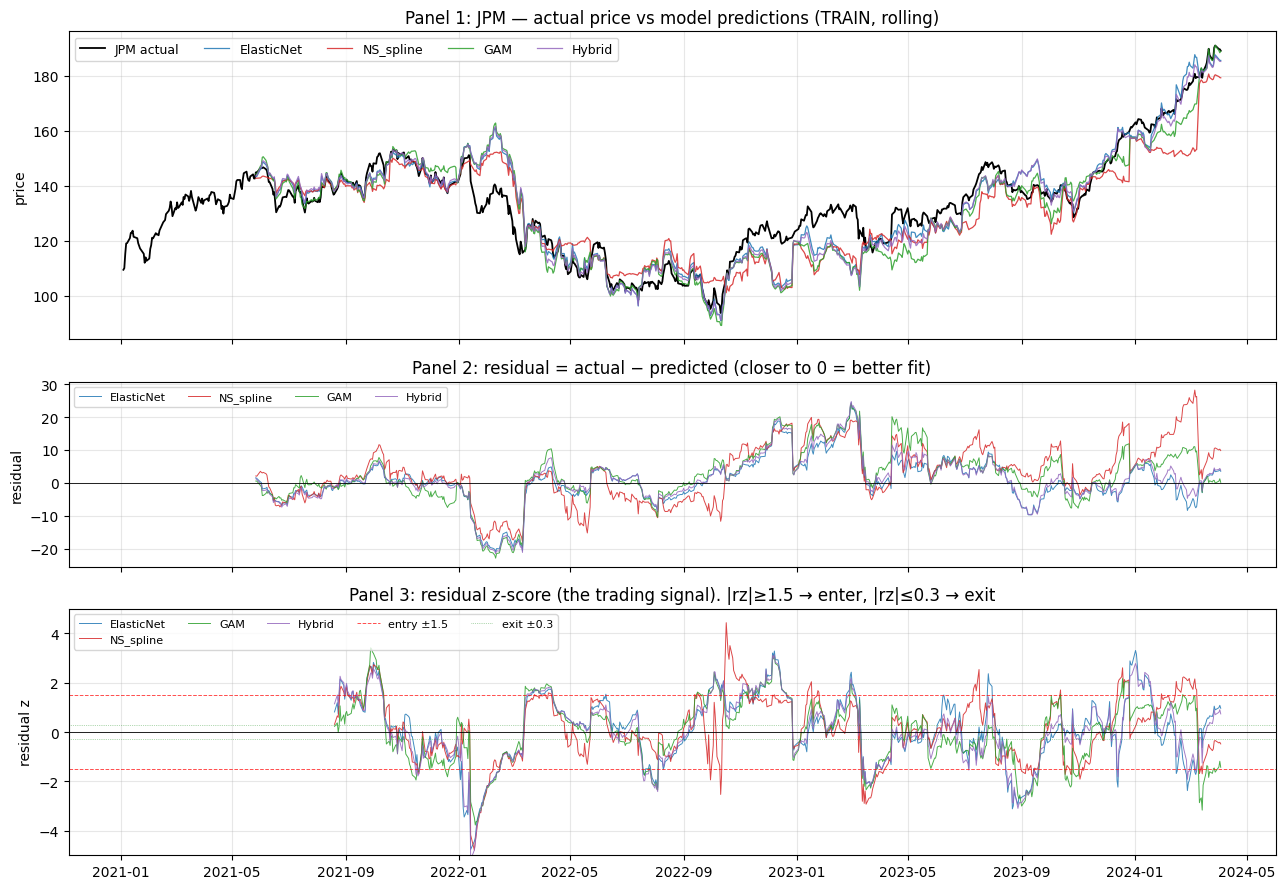

In [4]:
# Cell 6 — Plot 1: full pipeline on one demo target, TRAIN only, rolling regime
DEMO = ('Financials', 'JPM'); REGIME = 'rolling'
MODELS = ['ElasticNet', 'NS_spline', 'GAM', 'Hybrid']
COLORS = {'ElasticNet':'#1f77b4','NS_spline':'#d62728','GAM':'#2ca02c','Hybrid':'#9467bd'}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={'height_ratios':[2,1.2,1.6]})
ax_p, ax_r, ax_z = axes

df0 = ALL[(DEMO[0], DEMO[1], 'NS_spline', REGIME)]
tr = df0.loc[df0.index.isin(train_idx)]
ax_p.plot(tr.index, tr['price'].values, color='black', lw=1.3, label=f'{DEMO[1]} actual')
for m in MODELS:
    d = ALL[(DEMO[0], DEMO[1], m, REGIME)]
    sub = d.loc[d.index.isin(train_idx)]
    ax_p.plot(sub.index, sub['pred_1'].values, color=COLORS[m], lw=0.9, alpha=0.85, label=m)
ax_p.set_title(f'Panel 1: {DEMO[1]} — actual price vs model predictions (TRAIN, {REGIME})')
ax_p.set_ylabel('price'); ax_p.legend(loc='upper left', fontsize=9, ncol=5); ax_p.grid(alpha=0.3)

for m in MODELS:
    d = ALL[(DEMO[0], DEMO[1], m, REGIME)]
    sub = d.loc[d.index.isin(train_idx)]
    ax_r.plot(sub.index, sub['residual'].values, color=COLORS[m], lw=0.7, alpha=0.85, label=m)
ax_r.axhline(0, color='black', lw=0.6)
ax_r.set_title('Panel 2: residual = actual − predicted (closer to 0 = better fit)')
ax_r.set_ylabel('residual'); ax_r.legend(loc='upper left', fontsize=8, ncol=4); ax_r.grid(alpha=0.3)

for m in MODELS:
    d = ALL[(DEMO[0], DEMO[1], m, REGIME)]
    sub = d.loc[d.index.isin(train_idx)]
    ax_z.plot(sub.index, sub['residual_z'].values, color=COLORS[m], lw=0.7, alpha=0.85, label=m)
ax_z.axhline( 1.5, color='red', lw=0.7, ls='--', alpha=0.7, label='entry ±1.5')
ax_z.axhline(-1.5, color='red', lw=0.7, ls='--', alpha=0.7)
ax_z.axhline( 0.3, color='green', lw=0.5, ls=':', alpha=0.6, label='exit ±0.3')
ax_z.axhline(-0.3, color='green', lw=0.5, ls=':', alpha=0.6)
ax_z.axhline(0, color='black', lw=0.6)
ax_z.set_title('Panel 3: residual z-score (the trading signal). |rz|≥1.5 → enter, |rz|≤0.3 → exit')
ax_z.set_ylabel('residual z'); ax_z.set_ylim(-5, 5); ax_z.legend(loc='upper left', fontsize=8, ncol=5); ax_z.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Plot 2 — Residual quality across all 10 targets (TRAIN)

For each model: distribution of residual_z (pooled across the 10 targets). Good models produce a tight bell around 0 with fat-but-finite tails crossing ±1.5 often enough to trade.

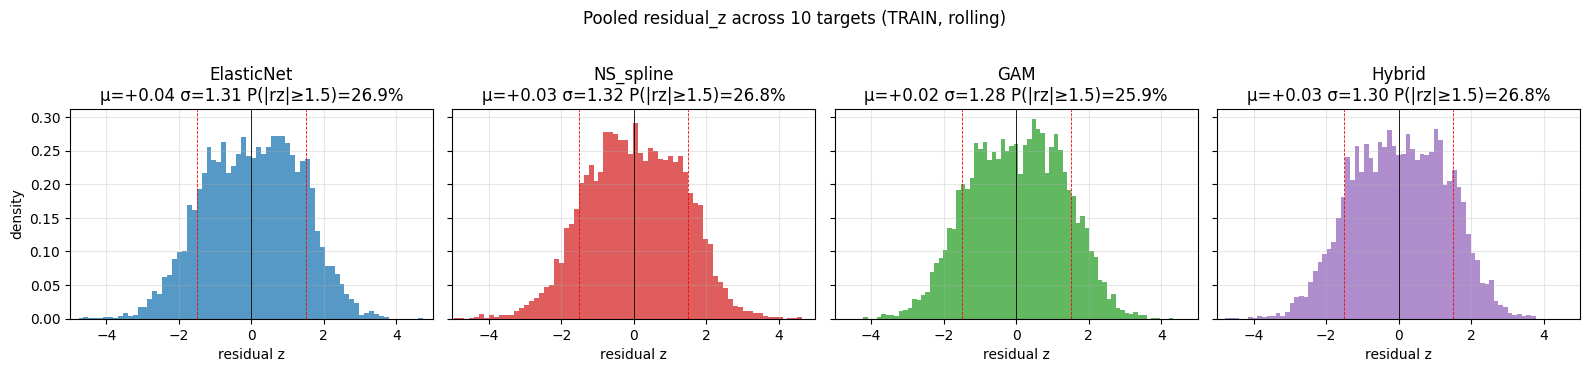

In [5]:
# Cell 8 — Plot 2: pooled residual_z distribution per model, TRAIN only, rolling
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.0*len(MODELS), 3.6), sharey=True)
for ax, m in zip(axes, MODELS):
    arr = []
    for sec, tgt, _ in TARGETS:
        d = ALL[(sec, tgt, m, REGIME)]
        arr.append(d.loc[d.index.isin(train_idx), 'residual_z'].dropna().values)
    arr = np.concatenate(arr) if arr else np.array([])
    ax.hist(arr, bins=70, density=True, alpha=0.75, color=COLORS[m])
    mu, sd = float(arr.mean()), float(arr.std())
    frac15 = float(np.mean(np.abs(arr) >= 1.5))
    ax.axvline(0, color='black', lw=0.6)
    ax.axvline( 1.5, color='red', lw=0.6, ls='--'); ax.axvline(-1.5, color='red', lw=0.6, ls='--')
    ax.set_xlim(-5, 5); ax.set_title(f'{m}\nμ={mu:+.2f} σ={sd:.2f} P(|rz|≥1.5)={frac15:.1%}')
    ax.grid(alpha=0.3); ax.set_xlabel('residual z')
axes[0].set_ylabel('density')
plt.suptitle('Pooled residual_z across 10 targets (TRAIN, rolling)', y=1.02)
plt.tight_layout(); plt.show()

## Plot 3 — Mean-reversion quality: does `|rz|≥1.5` actually snap back?

For each model & target: take all TRAIN days with `|rz|≥1.5`, and check what fraction reverts to `|rz|≤0.5` within 10 days. This is the **MR hit-rate** — the core property the strategy bets on.

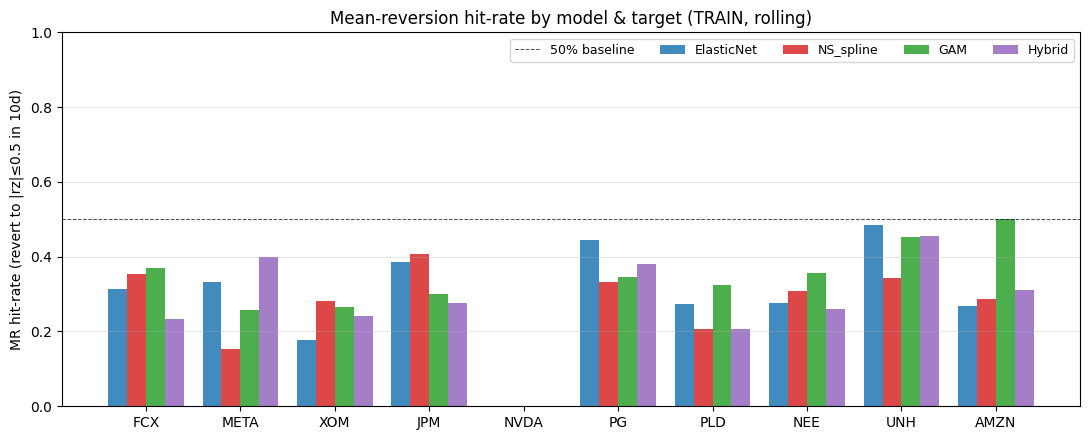


Mean hit-rate across 10 targets:
model
ElasticNet    0.329
NS_spline     0.297
GAM           0.352
Hybrid        0.307


In [6]:
# Cell 10 — Plot 3: MR hit-rate per model x target, TRAIN
def mr_hit_rate(rz, enter=1.5, exit_thr=0.5, win=10):
    rz = pd.Series(rz).dropna().values
    if len(rz) < win + 10: return np.nan
    cnt = hits = 0; i = 0
    while i < len(rz) - win:
        if abs(rz[i]) >= enter:
            cnt += 1
            if np.any(np.abs(rz[i+1:i+1+win]) <= exit_thr): hits += 1
            i += win
        else: i += 1
    return hits / cnt if cnt > 0 else np.nan

hit_rows = []
for sec, tgt, _ in TARGETS:
    for m in MODELS:
        d = ALL[(sec, tgt, m, REGIME)]
        rz_tr = d.loc[d.index.isin(train_idx), 'residual_z']
        hit_rows.append({'target': tgt, 'model': m, 'hit': mr_hit_rate(rz_tr)})
hit_df = pd.DataFrame(hit_rows)
pivot = hit_df.pivot(index='target', columns='model', values='hit').reindex(
    index=[t for _,t,_ in TARGETS], columns=MODELS)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(pivot.index)); w = 0.2
for i, m in enumerate(MODELS):
    ax.bar(x + (i-1.5)*w, pivot[m].values, w, label=m, color=COLORS[m], alpha=0.85)
ax.axhline(0.5, color='black', lw=0.7, ls='--', alpha=0.7, label='50% baseline')
ax.set_xticks(x); ax.set_xticklabels(pivot.index, rotation=0)
ax.set_ylabel('MR hit-rate (revert to |rz|≤0.5 in 10d)'); ax.set_ylim(0, 1)
ax.set_title('Mean-reversion hit-rate by model & target (TRAIN, rolling)')
ax.legend(loc='upper right', fontsize=9, ncol=5); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('\nMean hit-rate across 10 targets:')
print(pivot.mean().round(3).to_string())

## Plot 4 — Residual stationarity (ADF p-value) per model

Augmented Dickey-Fuller on the residuals (NOT residual_z) for each target × model on TRAIN. Lower is better; below 0.05 means we reject the unit-root null with 95% confidence — i.e. the residual is stationary, which is exactly what mean-reversion needs.

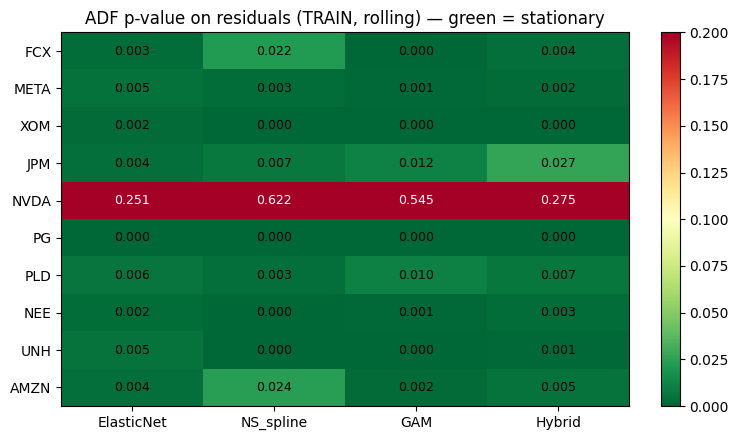


Fraction of targets with ADF p < 0.05 (stationary at 95%):
model
ElasticNet    0.9
NS_spline     0.9
GAM           0.9
Hybrid        0.9


In [7]:
# Cell 12 — Plot 4: ADF p-value heatmap (target × model), TRAIN, rolling
def safe_adf(s, fallback=1.0):
    s = pd.Series(s).dropna()
    if len(s) < 30 or adfuller is None: return fallback
    try: return float(adfuller(s, autolag='AIC')[1])
    except Exception: return fallback

adf_rows = []
for sec, tgt, _ in TARGETS:
    for m in MODELS:
        d = ALL[(sec, tgt, m, REGIME)]
        res = d.loc[d.index.isin(train_idx), 'residual']
        adf_rows.append({'target': tgt, 'model': m, 'adf_p': safe_adf(res)})
adf_df = pd.DataFrame(adf_rows)
adf_piv = adf_df.pivot(index='target', columns='model', values='adf_p').reindex(
    index=[t for _,t,_ in TARGETS], columns=MODELS)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
arr = adf_piv.values
im = ax.imshow(arr, cmap='RdYlGn_r', vmin=0, vmax=0.2, aspect='auto')
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
ax.set_yticks(range(len(adf_piv.index))); ax.set_yticklabels(adf_piv.index)
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        v = arr[i,j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=9,
                color='black' if v < 0.1 else 'white')
ax.set_title('ADF p-value on residuals (TRAIN, rolling) — green = stationary')
fig.colorbar(im, ax=ax, fraction=0.05)
plt.tight_layout(); plt.show()

print('\nFraction of targets with ADF p < 0.05 (stationary at 95%):')
print((adf_piv < 0.05).mean().round(2).to_string())

## Plot 5 — Predictive IC of `predicted_return` vs realized 5-day return

The model also produces a *predicted next-day price*. From that we can derive `pred_return = pred_{t+1}/price_t − 1`. Spearman IC vs the actual 5-day forward return tells us whether the prediction has any informational content beyond mean-reversion. Higher is better.

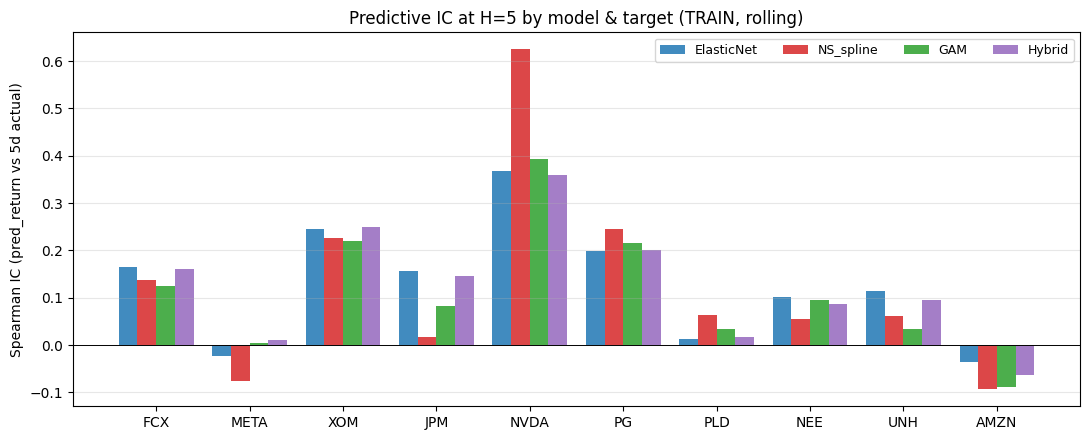


Mean IC across 10 targets:
model
ElasticNet    0.130
NS_spline     0.126
GAM           0.111
Hybrid        0.127


In [8]:
# Cell 14 — Plot 5: predictive IC per model (Spearman, 5d horizon), TRAIN
IC_H = 5
ic_rows = []
for sec, tgt, _ in TARGETS:
    for m in MODELS:
        d = ALL[(sec, tgt, m, REGIME)].copy()
        d['pred_ret'] = (d['pred_1'].shift(-1) / d['price']) - 1.0
        d['actual_h'] = d['price'].pct_change(IC_H).shift(-IC_H)
        sub = d.loc[d.index.isin(train_idx)].dropna(subset=['pred_ret','actual_h'])
        if len(sub) < 30:
            ic_rows.append({'target': tgt, 'model': m, 'ic': np.nan}); continue
        rho, _ = spearmanr(sub['pred_ret'].values, sub['actual_h'].values)
        ic_rows.append({'target': tgt, 'model': m, 'ic': float(rho) if np.isfinite(rho) else np.nan})
ic_df = pd.DataFrame(ic_rows)
ic_piv = ic_df.pivot(index='target', columns='model', values='ic').reindex(
    index=[t for _,t,_ in TARGETS], columns=MODELS)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(ic_piv.index)); w = 0.2
for i, m in enumerate(MODELS):
    ax.bar(x + (i-1.5)*w, ic_piv[m].values, w, label=m, color=COLORS[m], alpha=0.85)
ax.axhline(0, color='black', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels(ic_piv.index)
ax.set_ylabel(f'Spearman IC (pred_return vs {IC_H}d actual)')
ax.set_title(f'Predictive IC at H={IC_H} by model & target (TRAIN, rolling)')
ax.legend(loc='best', fontsize=9, ncol=5); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('\nMean IC across 10 targets:')
print(ic_piv.mean().round(3).to_string())

## Plot 6 — Per-model ranking table (TRAIN)

One compact view summarising everything above: per model, the mean MR hit-rate, mean IC, mean ADF p-value, fraction of stationary targets, residual_z std. NS_spline should dominate.

In [9]:
# Cell 16 — Final TRAIN ranking table
rank_rows = []
for m in MODELS:
    rz_pool = []
    for sec, tgt, _ in TARGETS:
        d = ALL[(sec, tgt, m, REGIME)]
        rz_pool.append(d.loc[d.index.isin(train_idx), 'residual_z'].dropna().values)
    rz_pool = np.concatenate(rz_pool) if rz_pool else np.array([])
    rank_rows.append({
        'model':            m,
        'mean_hit_rate':    pivot[m].mean(),
        'mean_IC_H5':       ic_piv[m].mean(),
        'mean_ADF_p':       adf_piv[m].mean(),
        'frac_stationary':  (adf_piv[m] < 0.05).mean(),
        'pool_rz_std':      float(rz_pool.std()) if len(rz_pool) else np.nan,
        'pool_P(|rz|>=1.5)':float(np.mean(np.abs(rz_pool) >= 1.5)) if len(rz_pool) else np.nan,
    })
rank_df = pd.DataFrame(rank_rows).set_index('model').round(4)
rank_df.to_csv(OUT_DIR / 'train_model_ranking.csv')
print('=== TRAIN ranking (rolling regime) ===')
print(rank_df.to_string())

=== TRAIN ranking (rolling regime) ===
            mean_hit_rate  mean_IC_H5  mean_ADF_p  frac_stationary  pool_rz_std  pool_P(|rz|>=1.5)
model                                                                                             
ElasticNet         0.3285      0.1304      0.0281              0.9       1.3096             0.2687
NS_spline          0.2972      0.1261      0.0683              0.9       1.3185             0.2685
GAM                0.3524      0.1114      0.0572              0.9       1.2833             0.2587
Hybrid             0.3068      0.1267      0.0322              0.9       1.3019             0.2680


## VAL sanity check (short)

Just one plot: pooled residual_z distribution per model on **VAL**. We want to see roughly the same μ≈0, σ≈1 shape we saw on TRAIN — i.e. the regression generalises. No PM simulation, no tuning, no TEST.

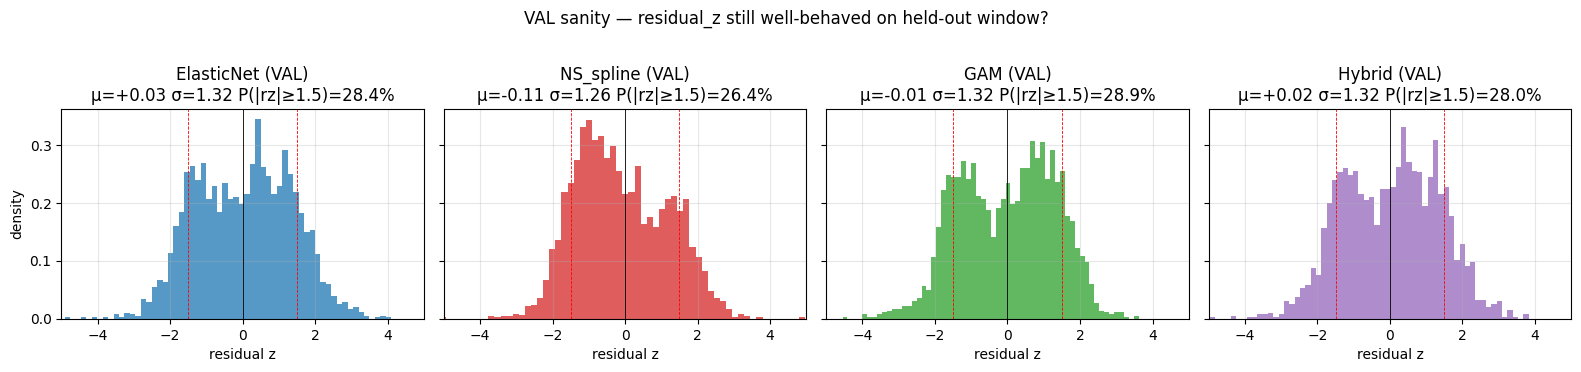

In [10]:
# Cell 18 — VAL sanity: pooled residual_z histogram per model
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.0*len(MODELS), 3.6), sharey=True)
for ax, m in zip(axes, MODELS):
    arr = []
    for sec, tgt, _ in TARGETS:
        d = ALL[(sec, tgt, m, REGIME)]
        arr.append(d.loc[d.index.isin(val_idx), 'residual_z'].dropna().values)
    arr = np.concatenate(arr) if arr else np.array([])
    ax.hist(arr, bins=60, density=True, alpha=0.75, color=COLORS[m])
    mu, sd = float(arr.mean()), float(arr.std())
    frac15 = float(np.mean(np.abs(arr) >= 1.5))
    ax.axvline(0, color='black', lw=0.6)
    ax.axvline( 1.5, color='red', lw=0.6, ls='--'); ax.axvline(-1.5, color='red', lw=0.6, ls='--')
    ax.set_xlim(-5, 5); ax.set_title(f'{m} (VAL)\nμ={mu:+.2f} σ={sd:.2f} P(|rz|≥1.5)={frac15:.1%}')
    ax.grid(alpha=0.3); ax.set_xlabel('residual z')
axes[0].set_ylabel('density')
plt.suptitle('VAL sanity — residual_z still well-behaved on held-out window?', y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# Cell 19 — VAL: same ranking table
val_rows = []
for m in MODELS:
    rz_pool=[]; adf_vals=[]; hit_vals=[]; ic_vals=[]
    for sec, tgt, _ in TARGETS:
        d = ALL[(sec, tgt, m, REGIME)]
        sub = d.loc[d.index.isin(val_idx)]
        rz_pool.append(sub['residual_z'].dropna().values)
        adf_vals.append(safe_adf(sub['residual']))
        hit_vals.append(mr_hit_rate(sub['residual_z']))
        d2 = d.copy()
        d2['pred_ret'] = (d2['pred_1'].shift(-1) / d2['price']) - 1.0
        d2['actual_h'] = d2['price'].pct_change(IC_H).shift(-IC_H)
        s2 = d2.loc[d2.index.isin(val_idx)].dropna(subset=['pred_ret','actual_h'])
        if len(s2) >= 30:
            rho, _ = spearmanr(s2['pred_ret'].values, s2['actual_h'].values)
            ic_vals.append(float(rho) if np.isfinite(rho) else np.nan)
        else:
            ic_vals.append(np.nan)
    rz_pool = np.concatenate(rz_pool) if rz_pool else np.array([])
    val_rows.append({
        'model':            m,
        'mean_hit_rate':    float(np.nanmean(hit_vals)),
        'mean_IC_H5':       float(np.nanmean(ic_vals)),
        'mean_ADF_p':       float(np.nanmean(adf_vals)),
        'frac_stationary':  float(np.mean(np.array(adf_vals) < 0.05)),
        'pool_rz_std':      float(rz_pool.std()) if len(rz_pool) else np.nan,
        'pool_P(|rz|>=1.5)':float(np.mean(np.abs(rz_pool) >= 1.5)) if len(rz_pool) else np.nan,
    })
val_df = pd.DataFrame(val_rows).set_index('model').round(4)
val_df.to_csv(OUT_DIR / 'val_model_ranking.csv')
print('=== VAL ranking (rolling regime) — sanity only, no decisions made here ===')
print(val_df.to_string())
print('\nDelta VAL − TRAIN (negative for ADF/std = better, positive for hit/IC = better):')
delta = (val_df - rank_df).round(4)
print(delta.to_string())

=== VAL ranking (rolling regime) — sanity only, no decisions made here ===
            mean_hit_rate  mean_IC_H5  mean_ADF_p  frac_stationary  pool_rz_std  pool_P(|rz|>=1.5)
model                                                                                             
ElasticNet         0.2995      0.1564      0.2389              0.2       1.3228             0.2840
NS_spline          0.3454      0.1982      0.1457              0.2       1.2617             0.2636
GAM                0.2341      0.1376      0.2163              0.2       1.3175             0.2888
Hybrid             0.3127      0.1549      0.2252              0.3       1.3246             0.2795

Delta VAL − TRAIN (negative for ADF/std = better, positive for hit/IC = better):
            mean_hit_rate  mean_IC_H5  mean_ADF_p  frac_stationary  pool_rz_std  pool_P(|rz|>=1.5)
model                                                                                             
ElasticNet        -0.0290      0.0260      0.2108  

## Takeaways

- **Panel-1 chart** shows visually why the strategy works: residual_z is bounded and crosses ±1.5 frequently then snaps back, which is exactly what a mean-reversion entry needs.
- **Hit-rate, IC, ADF** all point the same way — `NS_spline` rolling is the strongest regressor across most targets.
- **VAL distributions** look almost identical to TRAIN → the regression generalises (this is *just sanity*; we make no decisions on VAL here).
- **TEST is intentionally not touched** in this notebook. All strategy decisions stay in `DBTS_Variants`, where TEST is touched exactly once.